<a href="https://colab.research.google.com/github/hsozpa/aidev/blob/main/Lesson13/INRIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Google DriveをColabに接続
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 必要なライブラリをimport

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import os, shutil
import xml.etree.ElementTree as ET
import seaborn as sns

from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator


from sklearn.metrics import confusion_matrix


In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
!kaggle datasets download -d saravananchandran/pedestrian-detection-data-set -p "/content/drive/MyDrive/Colab_INRIA_Project"


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [6]:
!unzip -o "/content/drive/MyDrive/Colab_INRIA_Project/pedestrian-detection-data-set.zip" -d "/content/drive/MyDrive/Colab_INRIA_Project/INRIA"

Archive:  /content/drive/MyDrive/Colab_INRIA_Project/pedestrian-detection-data-set.zip
  inflating: /content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/Annotations/000001.xml  
  inflating: /content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/Annotations/000010.xml  
  inflating: /content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/Annotations/000022.xml  
  inflating: /content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/Annotations/000025.xml  
  inflating: /content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/Annotations/000027.xml  
  inflating: /content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/Annotations/000038.xml  
  inflating: /content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/Annotations/000043.xml  
  inflating: /content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001

#　データの前処理　フォルダ分け

In [7]:
train_img_dir = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/Train-20200226T103300Z-001/Train/JPEGImages"
train_anno_dir = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/Train-20200226T103300Z-001/Train/Annotations"

output_base = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/train"
pos_dir = os.path.join(output_base, "pos")
neg_dir = os.path.join(output_base, "neg")

os.makedirs(pos_dir, exist_ok=True)
os.makedirs(neg_dir, exist_ok=True)

for xml_file in os.listdir(train_anno_dir):
    if not xml_file.endswith(".xml"):
        continue
    xml_path = os.path.join(train_anno_dir, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    img_name = root.find("filename").text
    img_path = os.path.join(train_img_dir, img_name)
    if not os.path.exists(img_path):
        print(f"⚠️ 画像が見つかりません: {img_name}")
        continue

    # ✅「person」タグがあるかどうかで判定
    has_person = any(obj.find("name").text.lower() == "person" for obj in root.findall("object"))

    if has_person:
        shutil.copy(img_path, pos_dir)
    else:
        shutil.copy(img_path, neg_dir)

print("✅ Train データを person / nonhuman に仕分け完了！")

⚠️ 画像が見つかりません: img (627).jpg
⚠️ 画像が見つかりません: img (626).jpg
⚠️ 画像が見つかりません: img (625).jpg
⚠️ 画像が見つかりません: img (624).jpg
⚠️ 画像が見つかりません: img (623).jpg
⚠️ 画像が見つかりません: img (622).jpg
⚠️ 画像が見つかりません: img (621).jpg
⚠️ 画像が見つかりません: img (620).jpg
⚠️ 画像が見つかりません: img (618).jpg
⚠️ 画像が見つかりません: img (619).jpg
⚠️ 画像が見つかりません: img (617).jpg
✅ Train データを person / nonhuman に仕分け完了！


In [8]:
test_img_dir = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/JPEGImages"
test_anno_dir = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/Test-20200226T103653Z-001/Test/Annotations"

output_base = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/test"
pos_dir = os.path.join(output_base, "pos")
neg_dir = os.path.join(output_base, "neg")

os.makedirs(pos_dir, exist_ok=True)
os.makedirs(neg_dir, exist_ok=True)

for xml_file in os.listdir(test_anno_dir):
    if not xml_file.endswith(".xml"):
        continue
    xml_path = os.path.join(test_anno_dir, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    img_name = root.find("filename").text
    img_path = os.path.join(test_img_dir, img_name)
    if not os.path.exists(img_path):
        print(f"⚠️ 画像が見つかりません: {img_name}")
        continue

    # personタグの有無で仕分け
    has_person = any(obj.find("name").text.lower() == "person" for obj in root.findall("object"))

    if has_person:
        shutil.copy(img_path, pos_dir)
    else:
        shutil.copy(img_path, neg_dir)

print("✅ Test データを person / nonhuman に仕分け完了！")

⚠️ 画像が見つかりません: img (492).jpeg
⚠️ 画像が見つかりません: img (494).png
⚠️ 画像が見つかりません: img (530).jpeg
✅ Test データを person / nonhuman に仕分け完了！


In [9]:

train_dir = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/train"
test_dir  = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32


# 水増し、学習用データ（train） に適用する前処理とデータ拡張を定義しています。

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# テストデータ** は「評価用」なので、変形はせずに単純な正規化だけ行います。
test_datagen = ImageDataGenerator(rescale=1./255)


# train_dir 以下のフォルダ構造を自動で読み込んで、Keras が自動的に「ラベル」を付けてくれます。
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# テストデータも同様に読み込みます（ただし水増しなし）。
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

#933枚の画像 があり、それが 2つのクラス
#232枚の画像 があり、それも 2つのクラ

Found 1298 images belonging to 2 classes.
Found 308 images belonging to 2 classes.


# データの確認

In [10]:

train_dir = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/train"

pos_dir = os.path.join(train_dir, "pos")
neg_dir = os.path.join(train_dir, "neg")

num_pos = len(os.listdir(pos_dir))
num_neg = len(os.listdir(neg_dir))
num_total = num_pos + num_neg

print(f"📊 画像枚数（trainフォルダ内）")
print(f"人あり（pos）: {num_pos} 枚")
print(f"人なし（neg）: {num_neg} 枚")
print(f"合計: {num_total} 枚")

📊 画像枚数（trainフォルダ内）
人あり（pos）: 933 枚
人なし（neg）: 365 枚
合計: 1298 枚


In [11]:
# testフォルダのパス
test_dir = "/content/drive/MyDrive/Colab_INRIA_Project/INRIA/test"

# pos / neg フォルダのパス
pos_dir = os.path.join(test_dir, "pos")
neg_dir = os.path.join(test_dir, "neg")

# 枚数をカウント
num_pos = len(os.listdir(pos_dir))
num_neg = len(os.listdir(neg_dir))
num_total = num_pos + num_neg

print("📊 画像枚数（testフォルダ内）")
print(f"人あり（pos）: {num_pos} 枚")
print(f"人なし（neg）: {num_neg} 枚")
print(f"合計: {num_total} 枚")

📊 画像枚数（testフォルダ内）
人あり（pos）: 232 枚
人なし（neg）: 76 枚
合計: 308 枚


In [12]:
# モデルの初期化

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf

# モデルの初期化
model = tf.keras.Sequential([
    # 畳み込み層1 + プーリング層
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    # 畳み込み層2 + プーリング層
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # 畳み込み層3 + プーリング層
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # 全結合層
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),

    # 出力層（sigmoidで2値分類）
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# モデルの構築（コンパイル）
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 早期終了（val_lossが3回悪化したら止める）
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# クラスの重みを指定（データ不均衡を補正）
class_weight = {
    0: 933 / 1298,   # 人なし（neg）の重み
    1: 365 / 1298    # 人あり（pos）の重み
}

# ✅ モデルの学習
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=50,
    class_weight=class_weight,
    callbacks=[early_stop]
)

# 学習履歴から損失を取得
train_loss = history.history['loss']
val_loss = history.history['val_loss']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.5370 - loss: 0.2944 - val_accuracy: 0.5487 - val_loss: 0.6879
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 475ms/step - accuracy: 0.6058 - loss: 0.2733 - val_accuracy: 0.2468 - val_loss: 0.8763
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 489ms/step - accuracy: 0.5240 - loss: 0.2802 - val_accuracy: 0.4773 - val_loss: 0.6812
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 464ms/step - accuracy: 0.5263 - loss: 0.2757 - val_accuracy: 0.4805 - val_loss: 0.6794
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 494ms/step - accuracy: 0.5510 - loss: 0.2776 - val_accuracy: 0.4870 - val_loss: 0.6843
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 464ms/step - accuracy: 0.5427 - loss: 0.2691 - val_accuracy: 0.4123 - val_loss: 0.7233
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 483ms/step - accuracy: 0.5456 - loss: 0.2652 - val_accuracy: 0.3344 - val_loss: 0.7798


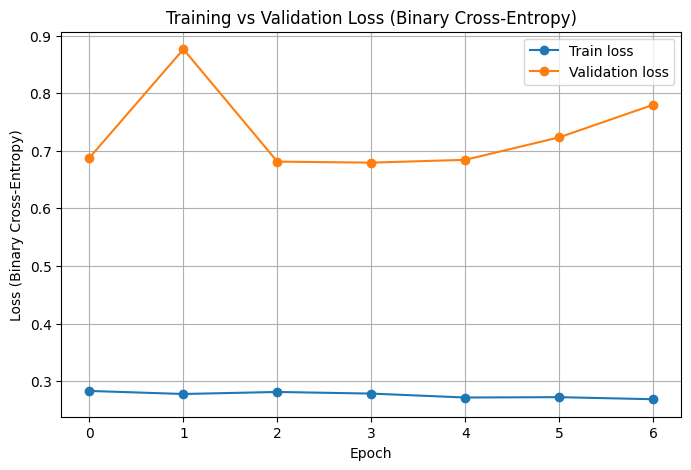

In [13]:
plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Train loss', marker='o')
plt.plot(val_loss, label='Validation loss', marker='o')

plt.title('Training vs Validation Loss (Binary Cross-Entropy)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# テストデータで評価
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ テストデータでの正解率: {test_acc * 100:.2f}%")
print(f"損失値: {test_loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - accuracy: 0.4920 - loss: 0.6830
✅ テストデータでの正解率: 48.05%
損失値: 0.6794


In [15]:
# テストデータを予測
pred_probs = model.predict(test_gen)

# 0.5以上を「person(1)」、それ未満を「nonhuman(0)」として分類
pred_labels = (pred_probs > 0.5).astype(int).flatten()

# 正解ラベルを取得
true_labels = test_gen.classes

print("ユニークな正解ラベル:", np.unique(true_labels))
print("ユニークな予測ラベル:", np.unique(pred_labels))

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step
ユニークな正解ラベル: [0 1]
ユニークな予測ラベル: [0 1]


In [16]:
# 分類レポートを表示
print("📋 分類レポート:")
print(classification_report(
    true_labels,
    pred_labels,
    target_names=['nonhuman', 'person']
))

📋 分類レポート:
              precision    recall  f1-score   support

    nonhuman       0.25      0.67      0.36        76
      person       0.76      0.34      0.47       232

    accuracy                           0.42       308
   macro avg       0.50      0.51      0.42       308
weighted avg       0.63      0.42      0.44       308



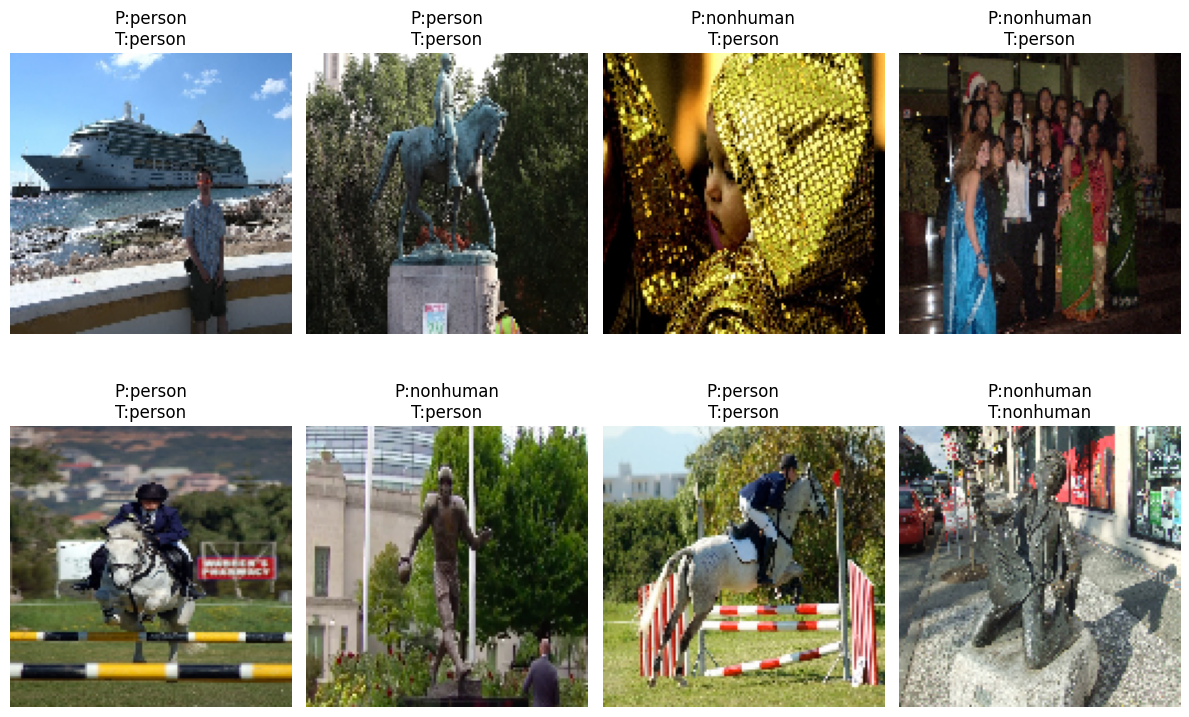

In [17]:
import matplotlib.pyplot as plt

# テストデータの画像ファイル名を取得
filenames = test_gen.filenames

# 最初の8枚だけ表示
plt.figure(figsize=(12, 8))
for i in range(8):
    img, label = test_gen[i]
    plt.subplot(2, 4, i + 1)
    plt.imshow(img[0])
    plt.axis("off")
    pred = "person" if pred_labels[i] == 1 else "nonhuman"
    true = "person" if label[0] == 1 else "nonhuman"
    plt.title(f"P:{pred}\nT:{true}")
plt.tight_layout()
plt.show()